In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [17]:
data = pd.read_csv('spam.csv', encoding='latin-1')

In [18]:
print(data)

        v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN        NaN  
1           NaN        NaN  


In [23]:
data = data.iloc[:, :2]   
data.columns = ['label', 'text']

In [24]:
print(data.head())

  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [26]:
data.shape

(5572, 2)

In [27]:
print(data.isnull().sum())

label    0
text     0
dtype: int64


In [28]:
data = data.drop_duplicates()

In [29]:
print("Dataset shape after cleaning:", data.shape)

Dataset shape after cleaning: (5169, 2)


In [30]:
data.rename(columns={'label': 'Category', 'text': 'Message'}, inplace=True)

In [31]:
data['Spam'] = data['Category'].apply(lambda x: 1 if x == 'spam' else 0)

In [32]:
data.head()

,Category,Message,Spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


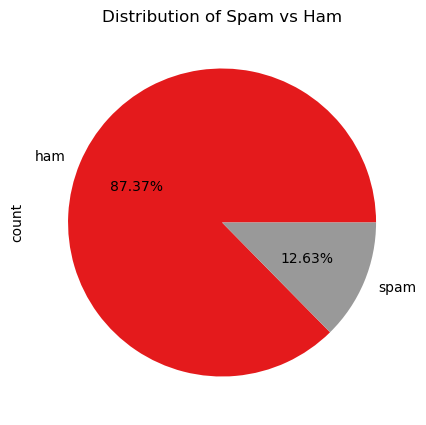

In [33]:
spread = data['Category'].value_counts()
plt.rcParams['figure.figsize'] = (5,5)

# Set Labels
spread.plot(kind = 'pie', autopct='%1.2f%%', cmap='Set1')
plt.title(f'Distribution of Spam vs Ham')

# Display the Chart
plt.show()

In [34]:
X = data['Message']
y = data['Spam']
print(data['Category'].unique())
print(data.head())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


['ham' 'spam']
  Category                                            Message  Spam
0      ham  Go until jurong point, crazy.. Available only ...     0
1      ham                      Ok lar... Joking wif u oni...     0
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...     1
3      ham  U dun say so early hor... U c already then say...     0
4      ham  Nah I don't think he goes to usf, he lives aro...     0


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [37]:
model = LogisticRegression(max_iter=1000, solver='liblinear')
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

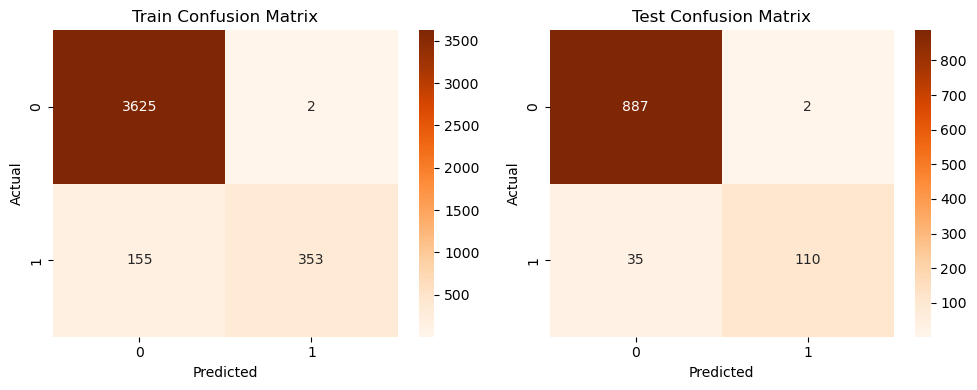

In [38]:
y_train_pred = model.predict(X_train_tfidf)
y_test_pred = model.predict(X_test_tfidf)
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Oranges')
plt.title('Train Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.subplot(1,2,2)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges')
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [42]:
print("Accuracy:", accuracy_score(y_test, y_test_pred)*100)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

Accuracy: 96.42166344294004

Confusion Matrix:
 [[887   2]
 [ 35 110]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       0.98      0.76      0.86       145

    accuracy                           0.96      1034
   macro avg       0.97      0.88      0.92      1034
weighted avg       0.96      0.96      0.96      1034



In [43]:
# Test on your own message
sample = ["Ok lar... Joking wif u oni...","Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"]

sample_tfidf = vectorizer.transform(sample)
predictions = model.predict(sample_tfidf)

for msg, pred in zip(sample, predictions):
    print(f"Message: {msg}")
    if pred == 1:
        print("Prediction: This is a spam email.")
    else:
        print("Prediction: This is a ham (non-spam) email.")
    print()


Message: Ok lar... Joking wif u oni...
Prediction: This is a ham (non-spam) email.

Message: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Prediction: This is a spam email.



In [44]:
import joblib
joblib.dump(model, 'spam_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')


['vectorizer.pkl']

In [45]:
import joblib

# Save model and vectorizer again
joblib.dump(model, 'spam_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

print("✅ Model and vectorizer saved successfully!")


✅ Model and vectorizer saved successfully!
